In [1]:
import pandas as pd
import os
import json
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.cluster.hierarchy as sch
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from matplotlib.ticker import MultipleLocator
import networkx as nx
from scipy.stats import zscore
import matplotlib
import umap

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


Load Human Protein Atlas data

In [3]:
original_df = pd.read_csv('../data/rna_single_cell_type.tsv', sep='\t')

Create a mapping between Gene and Gene name

In [4]:
gene_name_mapping = dict(zip(original_df['Gene'], original_df['Gene name']))

nTPM: normalized transcripts per million, a common unit for quantifying gene expression levels in transcriptomics. Specifically, it indicates that gene expression values have been normalized by transcript length and sequencing depth, making expression values comparable across genes and samples.

In [5]:
gene_celltype_df = original_df.pivot(index='Gene', columns='Cell type', values='nTPM')
gene_celltype_df.head()

Cell type,Adipocytes,Alveolar cells type 1,Alveolar cells type 2,Astrocytes,B-cells,Basal keratinocytes,Basal prostatic cells,Basal respiratory cells,Basal squamous epithelial cells,Bipolar cells,...,Spermatocytes,Spermatogonia,Squamous epithelial cells,Suprabasal keratinocytes,Syncytiotrophoblasts,T-cells,Undifferentiated cells,dendritic cells,granulocytes,monocytes
Gene,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003,147.5,6.0,10.9,13.6,1.5,12.7,14.0,74.1,23.9,0.6,...,17.4,31.5,23.5,45.6,12.0,2.3,74.8,0.0,5.2,0.0
ENSG00000000005,72.2,0.0,0.0,0.0,0.0,0.1,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.3,0.0,0.1,0.6,0.0,0.0,0.0
ENSG00000000419,37.8,40.9,41.3,25.7,29.5,86.9,38.2,234.7,29.0,12.6,...,117.9,95.3,31.5,80.6,265.5,39.0,66.4,58.8,34.6,52.7
ENSG00000000457,5.6,6.9,5.9,11.1,7.9,3.9,5.8,3.9,6.2,9.1,...,9.3,6.3,8.6,4.0,12.5,11.3,9.8,17.4,2.8,9.8
ENSG00000000460,1.4,1.7,2.4,4.0,4.5,2.2,1.2,2.1,1.3,6.1,...,36.9,15.2,2.7,0.9,4.2,3.6,5.1,0.4,1.6,2.6


In [6]:
# Proces
del gene_celltype_df["Undifferentiated cells"]
gene_celltype_df['Macrophages'] = gene_celltype_df[['Hofbauer cells', 'Kupffer cells', 'Langerhans cells',  'Macrophages']].mean(axis=1)
del gene_celltype_df['Hofbauer cells']
del gene_celltype_df['Kupffer cells']
del gene_celltype_df['Langerhans cells']

In [7]:
gene_celltype_df.columns

Index(['Adipocytes', 'Alveolar cells type 1', 'Alveolar cells type 2',
       'Astrocytes', 'B-cells', 'Basal keratinocytes', 'Basal prostatic cells',
       'Basal respiratory cells', 'Basal squamous epithelial cells',
       'Bipolar cells', 'Breast glandular cells', 'Breast myoepithelial cells',
       'Cardiomyocytes', 'Cholangiocytes', 'Ciliated cells', 'Club cells',
       'Collecting duct cells', 'Cone photoreceptor cells', 'Cytotrophoblasts',
       'Distal enterocytes', 'Distal tubular cells', 'Ductal cells',
       'Early spermatids', 'Endometrial stromal cells', 'Endothelial cells',
       'Enteroendocrine cells', 'Erythroid cells', 'Excitatory neurons',
       'Exocrine glandular cells', 'Extravillous trophoblasts', 'Fibroblasts',
       'Gastric mucus-secreting cells', 'Glandular and luminal cells',
       'Granulosa cells', 'Hepatocytes', 'Horizontal cells',
       'Inhibitory neurons', 'Intestinal goblet cells', 'Ionocytes',
       'Late spermatids', 'Leydig cells', 'Lym

Identify marker genes with fold enrichment or unqiue to target cell type

In [8]:
df_expression = gene_celltype_df
marker_genes = {}

# Iterate through each cell type to find enriched marker genes
for celltype in df_expression.columns:
    # Expression in target cell type
    target_expr = df_expression[celltype]
    other_expr_max = df_expression.drop(columns=[celltype]).max(axis=1)

    # Identify marker genes with at least 2-fold enrichment or unqiue to target cell type
    enriched_genes = target_expr[((target_expr >= 2 * other_expr_max) & (target_expr > 0)) |
                                 ((target_expr > 0) & (other_expr_max == 0))]

    marker_genes[celltype] = enriched_genes.index.tolist()

marker_genes_df = pd.DataFrame(dict([(k, pd.Series(v)) for k,v in marker_genes.items()]))

marker_genes_df.head()

,Adipocytes,Alveolar cells type 1,Alveolar cells type 2,Astrocytes,B-cells,Basal keratinocytes,Basal prostatic cells,Basal respiratory cells,Basal squamous epithelial cells,Bipolar cells,...,Smooth muscle cells,Spermatocytes,Spermatogonia,Squamous epithelial cells,Suprabasal keratinocytes,Syncytiotrophoblasts,T-cells,dendritic cells,granulocytes,monocytes
0,ENSG00000000005,ENSG00000005884,ENSG00000007402,ENSG00000056487,ENSG00000007312,ENSG00000065618,ENSG00000088782,ENSG00000017483,ENSG00000102195,ENSG00000006283,...,ENSG00000019991,ENSG00000004487,ENSG00000101883,ENSG00000006059,ENSG00000081277,ENSG00000006007,ENSG00000013725,ENSG00000060558,ENSG00000012779,ENSG00000000938
1,ENSG00000010319,ENSG00000013588,ENSG00000047936,ENSG00000064489,ENSG00000083454,ENSG00000147896,ENSG00000101446,ENSG00000087494,ENSG00000105996,ENSG00000058404,...,ENSG00000053702,ENSG00000008405,ENSG00000102021,ENSG00000159527,ENSG00000084733,ENSG00000006659,ENSG00000049768,ENSG00000070915,ENSG00000049249,ENSG00000005889
2,ENSG00000065054,ENSG00000086548,ENSG00000078081,ENSG00000066032,ENSG00000104894,ENSG00000179615,ENSG00000107560,ENSG00000115009,ENSG00000106004,ENSG00000072182,...,ENSG00000076706,ENSG00000012048,ENSG00000102048,ENSG00000177023,ENSG00000088002,ENSG00000007866,ENSG00000081059,ENSG00000078177,ENSG00000054983,ENSG00000011422
3,ENSG00000099250,ENSG00000092929,ENSG00000101417,ENSG00000067177,ENSG00000104921,ENSG00000186847,ENSG00000120457,ENSG00000124102,ENSG00000120471,ENSG00000100324,...,ENSG00000108700,ENSG00000027644,ENSG00000123576,ENSG00000184702,ENSG00000092295,ENSG00000007944,ENSG00000090554,ENSG00000086475,ENSG00000074771,ENSG00000015285
4,ENSG00000106511,ENSG00000105971,ENSG00000103811,ENSG00000068078,ENSG00000117322,ENSG00000197632,ENSG00000124157,ENSG00000128422,ENSG00000145777,ENSG00000100987,...,ENSG00000111404,ENSG00000047410,ENSG00000124900,ENSG00000198211,ENSG00000096696,ENSG00000035499,ENSG00000096264,ENSG00000102174,ENSG00000092009,ENSG00000018280


Check Somalogic coverage

In [9]:
# transform gene to gene name in marker_genes
marker_genes_df_save = pd.DataFrame([
    {'Original Cell types': cell_type, 'Marker Genes': ', '.join([gene_name_mapping[gene] for gene in genes])}
    for cell_type, genes in marker_genes.items()
])

In [ ]:
# load somalogic metadata
somalogic_metadata = pd.read_csv('../data/somalogic_7k_protein_metadata.csv')

In [12]:
gene_to_somamer = dict(zip(somalogic_metadata['EntrezGeneSymbol'], somalogic_metadata['Somamer']))

marker_genes_df_save['Somamers'] = marker_genes_df_save['Marker Genes'].apply(
    lambda x: [gene_to_somamer.get(gene.strip().strip("'").strip('"')) 
               for gene in x.strip('[]').split(',')])

marker_genes_df_save['Somamers'] = marker_genes_df_save['Somamers'].apply(
    lambda x: str([s for s in x if s is not None]))

marker_genes_df_save['Somamers'] = marker_genes_df_save['Marker Genes'].apply(
    lambda x: ', '.join([gene_to_somamer.get(gene.strip().strip("'").strip('"')) 
                        for gene in x.strip('[]').split(',')
                        if gene_to_somamer.get(gene.strip().strip("'").strip('"')) is not None]))

In [13]:
marker_genes_df_save

,Original Cell types,Marker Genes,Somamers
0,Adipocytes,"TNMD, SEMA3G, SLC9A3R2, NRP1, MEOX2, KIF25, TC...","TNMD.6578.29, SEMA3G.5628.21, NRP1.5542.22, ME..."
1,Alveolar cells type 1,"ITGA3, GPRC5A, CEACAM6, UNC13D, CAV2, DVL1, SP...","UNC13D.24942.22, CAV2.9457.3, SPOCK2.5491.12, ..."
2,Alveolar cells type 2,"CACNA2D2, ROS1, LAMP3, PXMP4, CTSH, ICAM4, SLC...","ROS1.9032.30, CTSH.8644.46, ICAM4.9461.2, SFTP..."
3,Astrocytes,"PHF21B, BORCS8-MEF2B, CTNNA2, PHKA1, FGFR3, EV...","CTNNA2.9872.23, PHKA1.25088.42, FGFR3.3809.1, ..."
4,B-cells,"CD79B, P2RX5, CD37, FCER2, CR2, LY9, NPBWR2, C...","CD79B.6351.55, CD37.18202.22, FCER2.3291.30, C..."
...,...,...,...
72,Syncytiotrophoblasts,"GDE1, LGALS14, TEAD3, MYLIP, DEPDC1B, SLC66A1,...","TEAD3.12854.3, UBE2A.17743.14, MAEA.21477.105,..."
73,T-cells,"CD6, FOXP3, TCF7, FLT3LG, NCR2, APOBEC3H, CD40...","CD6.20519.7, FOXP3.22148.135, FLT3LG.3053.49, ..."
74,dendritic cells,"GNA15, SLC12A3, N4BP2, SEPHS1, PHEX, SMPD3, SL...","SEPHS1.14083.25, PHEX.18921.30, NR3C1.2857.70,..."
75,granulocytes,"ALOX5, TNFRSF9, GALC, NOX3, CMA1, TPSD1, GRAP2...","ALOX5.25880.14, TNFRSF9.2598.9, CMA1.3423.59, ..."


Visualize expression from Huam Protein Atlas across cell types 

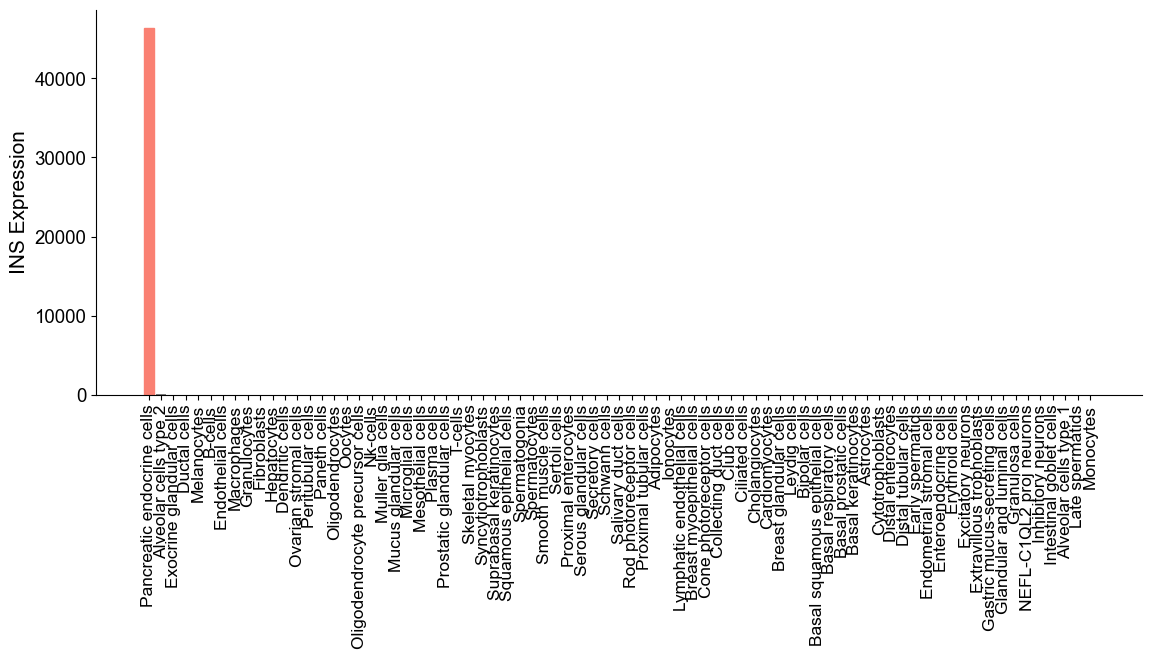

In [17]:
gene_id = None
for ensg, name in gene_name_mapping.items():
    if name == 'INS':
        gene_id = ensg
        break

expression = gene_celltype_df.loc[gene_id] 
sorted_expr = expression.sort_values(ascending=False)
sorted_expr = sorted_expr.rename(index={'Horizontal cells': 'NEFL-C1QL2 proj neurons'})

plt.figure(figsize=(13.5, 5))

plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['font.family'] = 'Arial'

bars = plt.bar(x=range(len(sorted_expr)), height=sorted_expr.values, color='gray')
bars[0].set_color('salmon')  # Highlight the top bar

x_labels = [cell_type.capitalize() for cell_type in sorted_expr.index]
x_labels = ['NEFL-C1QL2 proj neurons' if cell_type == 'NEFL-C1QL2 proj neurons' 
            else cell_type.capitalize() for cell_type in sorted_expr.index]

plt.xticks(range(len(sorted_expr)), x_labels, rotation=90, fontsize=12.5)
plt.yticks(fontsize=13.5)

plt.xlabel('', fontsize=13.5)
plt.ylabel('INS Expression', fontsize=15)
plt.title('', fontsize=16)
plt.show()

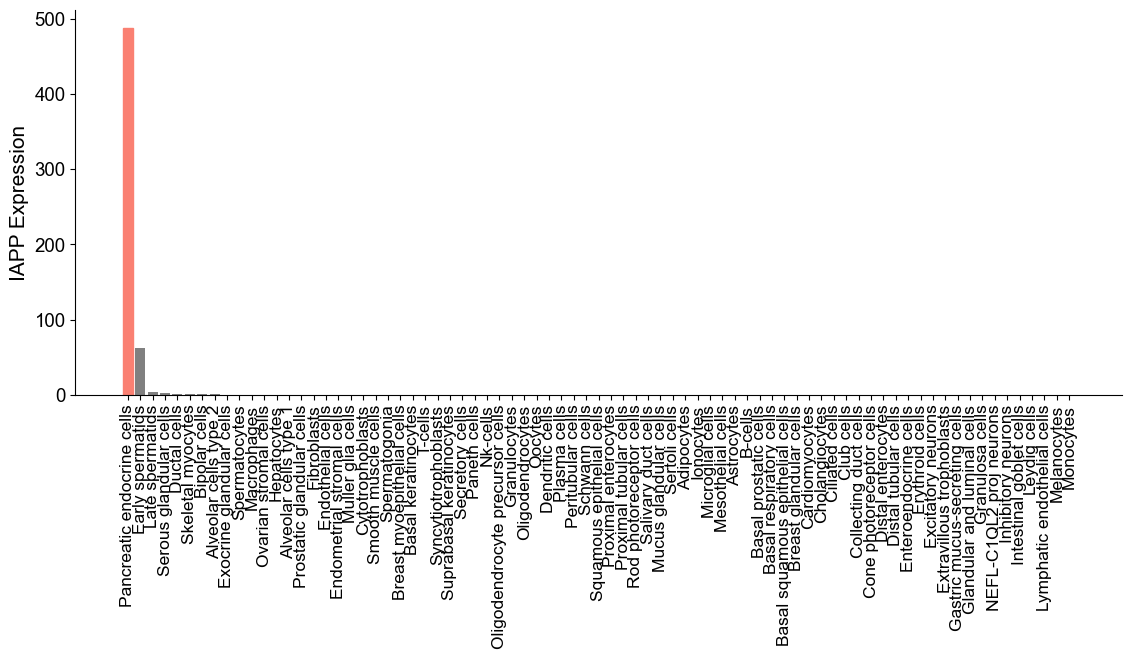

In [18]:
gene_id = None
for ensg, name in gene_name_mapping.items():
    if name == 'IAPP':
        gene_id = ensg
        break

expression = gene_celltype_df.loc[gene_id] 
sorted_expr = expression.sort_values(ascending=False)
sorted_expr = sorted_expr.rename(index={'Horizontal cells': 'NEFL-C1QL2 proj neurons'})

plt.figure(figsize=(13.5, 5))

bars = plt.bar(x=range(len(sorted_expr)), height=sorted_expr.values, color='gray')
bars[0].set_color('salmon')  # Highlight the top bar

x_labels = [cell_type.capitalize() for cell_type in sorted_expr.index]
x_labels = ['NEFL-C1QL2 proj neurons' if cell_type == 'NEFL-C1QL2 proj neurons' 
            else cell_type.capitalize() for cell_type in sorted_expr.index]

plt.xticks(range(len(sorted_expr)), x_labels, rotation=90, fontsize=12.5)
plt.yticks(fontsize=13.5)

plt.xlabel('', fontsize=13.5)
plt.ylabel('IAPP Expression', fontsize=15)
plt.title('', fontsize=16)
plt.show()

In [20]:
df_expression = gene_celltype_df
marker_genes = {}
marker_genes_enrichment = {}  # Dictionary to store enrichment information

# Iterate through each cell type to find enriched marker genes
for celltype in df_expression.columns:
    # Expression in target cell type
    target_expr = df_expression[celltype]
    
    # Get other cell types' expression
    other_cells = df_expression.drop(columns=[celltype])
    
    # Maximum expression in other cell types (for each gene)
    other_expr_max = other_cells.max(axis=1)
    
    # Average expression in other cell types (for each gene)
    other_expr_avg = other_cells.mean(axis=1)
    
    # Identify marker genes with at least 2-fold enrichment or unique to target cell type
    enriched_genes = target_expr[((target_expr >= 2 * other_expr_max) & (target_expr > 0)) |
                                 ((target_expr > 0) & (other_expr_max == 0))]
    
    marker_genes[celltype] = enriched_genes.index.tolist()
    
    # For each marker gene, calculate and store enrichment factors
    marker_enrichment_data = {}
    for gene_id in enriched_genes.index:
        gene_name = gene_name_mapping.get(gene_id, gene_id)  # Get gene name if available
        target_value = enriched_genes[gene_id]
        
        # Calculate enrichment vs max of other cell types
        max_others = other_expr_max[gene_id]
        vs_max_others = float('inf') if max_others == 0 else target_value / max_others
        
        # Calculate enrichment vs average of other cell types
        avg_others = other_expr_avg[gene_id]
        vs_avg_others = float('inf') if avg_others == 0 else target_value / avg_others
        
        # Check if gene has a corresponding Somalogic ID
        somamer_id = gene_to_somamer.get(gene_name)
        has_somamer = somamer_id is not None
        
        marker_enrichment_data[gene_id] = {
            'gene_name': gene_name,
            'expression_value': target_value,
            'max_other_cells': max_others,
            'vs_max_enrichment': vs_max_others,
            'avg_other_cells': avg_others,
            'vs_avg_enrichment': vs_avg_others,
            'somamer_id': somamer_id,
            'has_somamer': has_somamer
        }
    
    # Store enrichment data for this cell type
    marker_genes_enrichment[celltype] = marker_enrichment_data

marker_genes_df = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in marker_genes.items()]))

enrichment_data_all = []

for cell_type, genes_data in marker_genes_enrichment.items():
    for gene_id, enrichment_info in genes_data.items():
        row_data = {
            'cell_type': cell_type,
            'gene_id': gene_id,
            'gene_name': enrichment_info['gene_name'],
            'expression_value': enrichment_info['expression_value'],
            'max_other_cells': enrichment_info['max_other_cells'],
            'vs_max_enrichment': enrichment_info['vs_max_enrichment'],
            'avg_other_cells': enrichment_info['avg_other_cells'],
            'vs_avg_enrichment': enrichment_info['vs_avg_enrichment'],
            'somamer_id': enrichment_info['somamer_id'],
            'has_somamer': enrichment_info['has_somamer']
        }
        enrichment_data_all.append(row_data)

marker_genes_enrichment_df = pd.DataFrame(enrichment_data_all)

marker_genes_enrichment_df = marker_genes_enrichment_df.sort_values(
    ['cell_type', 'vs_avg_enrichment'], 
    ascending=[True, False]
)

# Create a Somalogic-specific dataframe for only genes with Somamer IDs
somalogic_markers_df = marker_genes_enrichment_df[marker_genes_enrichment_df['has_somamer'] == True].copy()

# Sort by cell type and enrichment
somalogic_markers_df = somalogic_markers_df.sort_values(
    ['cell_type', 'vs_avg_enrichment'], 
    ascending=[True, False]
)

somalogic_markers_df.head()

,cell_type,gene_id,gene_name,expression_value,max_other_cells,vs_max_enrichment,avg_other_cells,vs_avg_enrichment,somamer_id,has_somamer
12,Adipocytes,ENSG00000161649,CD300LG,505.1,40.0,12.627500,1.568092,322.111181,CD300LG.20585.9,True
18,Adipocytes,ENSG00000170323,FABP4,20163.4,1427.9,14.121017,66.831250,301.706163,FABP4.9851.9,True
13,Adipocytes,ENSG00000162444,RBP7,3296.7,200.8,16.417829,13.625329,241.953792,RBP7.14208.3,True
15,Adipocytes,ENSG00000165810,BTNL9,794.5,129.9,6.116243,6.086184,130.541563,BTNL9.7950.142,True
0,Adipocytes,ENSG00000000005,TNMD,72.2,11.6,6.224138,0.664474,108.657426,TNMD.6578.29,True


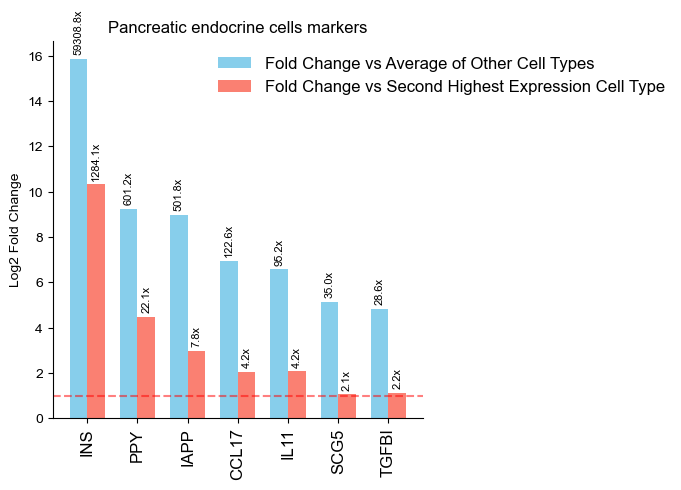

In [21]:
def plot_cell_type_somamer_markers(target_cell_type, figsize=(5, 5), legend=True):
    # Filter for the target cell type and genes with somamers
    cell_markers = marker_genes_enrichment_df[
        (marker_genes_enrichment_df['cell_type'] == target_cell_type) & 
        (marker_genes_enrichment_df['has_somamer'] == True)
    ].copy()
    
    if len(cell_markers) == 0:
        print(f"No markers with Somamer mappings found for {target_cell_type}")
        return f"No markers with Somamer mappings found for {target_cell_type}"
    
    # Apply log2 transformation
    import numpy as np
    cell_markers['vs_avg_log2'] = np.log2(cell_markers['vs_avg_enrichment'])
    cell_markers['vs_max_log2'] = np.log2(cell_markers['vs_max_enrichment'])
    
    # Sort markers by log2 average enrichment
    cell_markers = cell_markers.sort_values('vs_avg_log2', ascending=False)
    
    # Get gene names for x-axis labels
    gene_labels = cell_markers['gene_name'].tolist()
    
    fig, ax = plt.subplots(figsize=figsize)
    
    bar_width = 0.35
    
    r1 = np.arange(len(gene_labels))
    r2 = [x + bar_width for x in r1]
    
    avg_bars = ax.bar(r1, cell_markers['vs_avg_log2'], width=bar_width, color='skyblue', 
                      label='Fold Change vs Average of Other Cell Types')
    max_bars = ax.bar(r2, cell_markers['vs_max_log2'], width=bar_width, color='salmon', 
                      label='Fold Change vs Second Highest Expression Cell Type')

    for i, (idx, row) in enumerate(cell_markers.iterrows()):
        # Annotate average enrichment bar
        ax.annotate(f"{row['vs_avg_enrichment']:.1f}x", 
                xy=(r1[i], row['vs_avg_log2']),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom',
                fontsize=8, rotation=90)
        
        # Annotate max enrichment bar
        ax.annotate(f"{row['vs_max_enrichment']:.1f}x", 
                xy=(r2[i], row['vs_max_log2']),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom',
                fontsize=8, rotation=90)
    
    # Add horizontal line at log2(2) = 1
    ax.axhline(y=1, color='red', linestyle='--', alpha=0.5)
    
    ax.set_xlabel('', fontsize=10)
    ax.set_ylabel('Log2 Fold Change', fontsize=10)
    ax.set_title(f'{target_cell_type} markers', fontsize=12)
    ax.set_xticks([r + bar_width/2 for r in range(len(gene_labels))])
    ax.set_xticklabels(gene_labels, rotation=90, ha='center', fontsize=12)

    if legend:
        ax.legend(loc='upper center',  bbox_to_anchor=(1.05, 1), ncol=1, frameon=False, fontsize=12)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    return f"Successfully generated plot for {target_cell_type} markers with Somamer mappings."

result = plot_cell_type_somamer_markers('Pancreatic endocrine cells', figsize=(7, 5))